<a href="https://colab.research.google.com/github/jdmartinev/MachineLearning/blob/main/Talleres/MLComp01_Loan_Prediction_Notebook_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Prediction Competition

In this workshop, we will apply ensemble methods such as Random Forest and Gradient Boosting to a loan prediction dataset. The dataset used is a modified subset of the **Loan Prediction Problem Dataset** from Kaggle ([link](https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset)).

## Objective
The task is to predict whether a loan application will be approved based on applicant information.

![Loan Prediction Competition](https://drive.google.com/uc?id=1eipuAdG46mfAgm-KSFth_YEazhJAZHVx)



## Loading the Data

The training dataset is loaded from the **[train.csv](https://drive.google.com/file/d/1Ejs0yaRm3NxFOVIhwQphoDz8voJl6NQx/view?usp=sharing)** file using Pandas. After loading, we inspect the first few rows to understand its structure and check for missing values. Basic preprocessing steps, such as handling null values and encoding categorical variables, will be performed before modeling.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import shap

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [13]:
#!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1Ejs0yaRm3NxFOVIhwQphoDz8voJl6NQx' -O loanpred_train.csv

In [14]:
# Let's define the "random_state" to ensure reproducible results:
random_state=42

In [15]:
# Let's change the font of Matplotlib plots:
plt.rc('font', family='serif', size=12)

In [16]:
#Let's load the data
# Carguemos los datos:
data = pd.read_csv('train.csv')
data

,id,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001535,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,Y
1,LP001792,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,Y
2,LP002443,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,N
3,LP002517,Male,Yes,1,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural,N
4,LP001894,Male,Yes,0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,LP001744,Male,No,0,Graduate,No,2971,2791.0,144.0,360.0,1.0,Semiurban,Y
487,LP002138,Male,Yes,0,Graduate,No,2625,6250.0,187.0,360.0,1.0,Rural,Y
488,LP001068,Male,Yes,0,Graduate,No,2799,2253.0,122.0,360.0,1.0,Semiurban,Y
489,LP001327,Female,Yes,0,Graduate,No,2484,2302.0,137.0,360.0,1.0,Semiurban,Y


In [17]:
# Let's check the dataset description:
### CODE HERE ###
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 491 non-null    object 
 1   Gender             480 non-null    object 
 2   Married            488 non-null    object 
 3   Dependents         483 non-null    object 
 4   Education          491 non-null    object 
 5   Self_Employed      464 non-null    object 
 6   ApplicantIncome    491 non-null    int64  
 7   CoapplicantIncome  491 non-null    float64
 8   LoanAmount         471 non-null    float64
 9   Loan_Amount_Term   479 non-null    float64
 10  Credit_History     448 non-null    float64
 11  Property_Area      491 non-null    object 
 12  Loan_Status        491 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 50.0+ KB


In [18]:
data.isna().sum()

id                    0
Gender               11
Married               3
Dependents            8
Education             0
Self_Employed        27
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           20
Loan_Amount_Term     12
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [19]:
data.describe(include='all')

,id,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,491,480,488,483,491,464,491.000000,491.000000,471.000000,479.000000,448.000000,491,491
unique,491,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001535,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,393,319,276,380,398,NaN,NaN,NaN,NaN,NaN,184,337
mean,NaN,NaN,NaN,NaN,NaN,NaN,5529.997963,1569.537271,147.309979,341.286013,0.850446,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6457.784318,2789.523475,87.096507,65.855043,0.357032,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,210.000000,0.000000,9.000000,12.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2906.000000,0.000000,100.000000,360.000000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3859.000000,1032.000000,128.000000,360.000000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5825.000000,2241.000000,168.000000,360.000000,1.000000,NaN,NaN


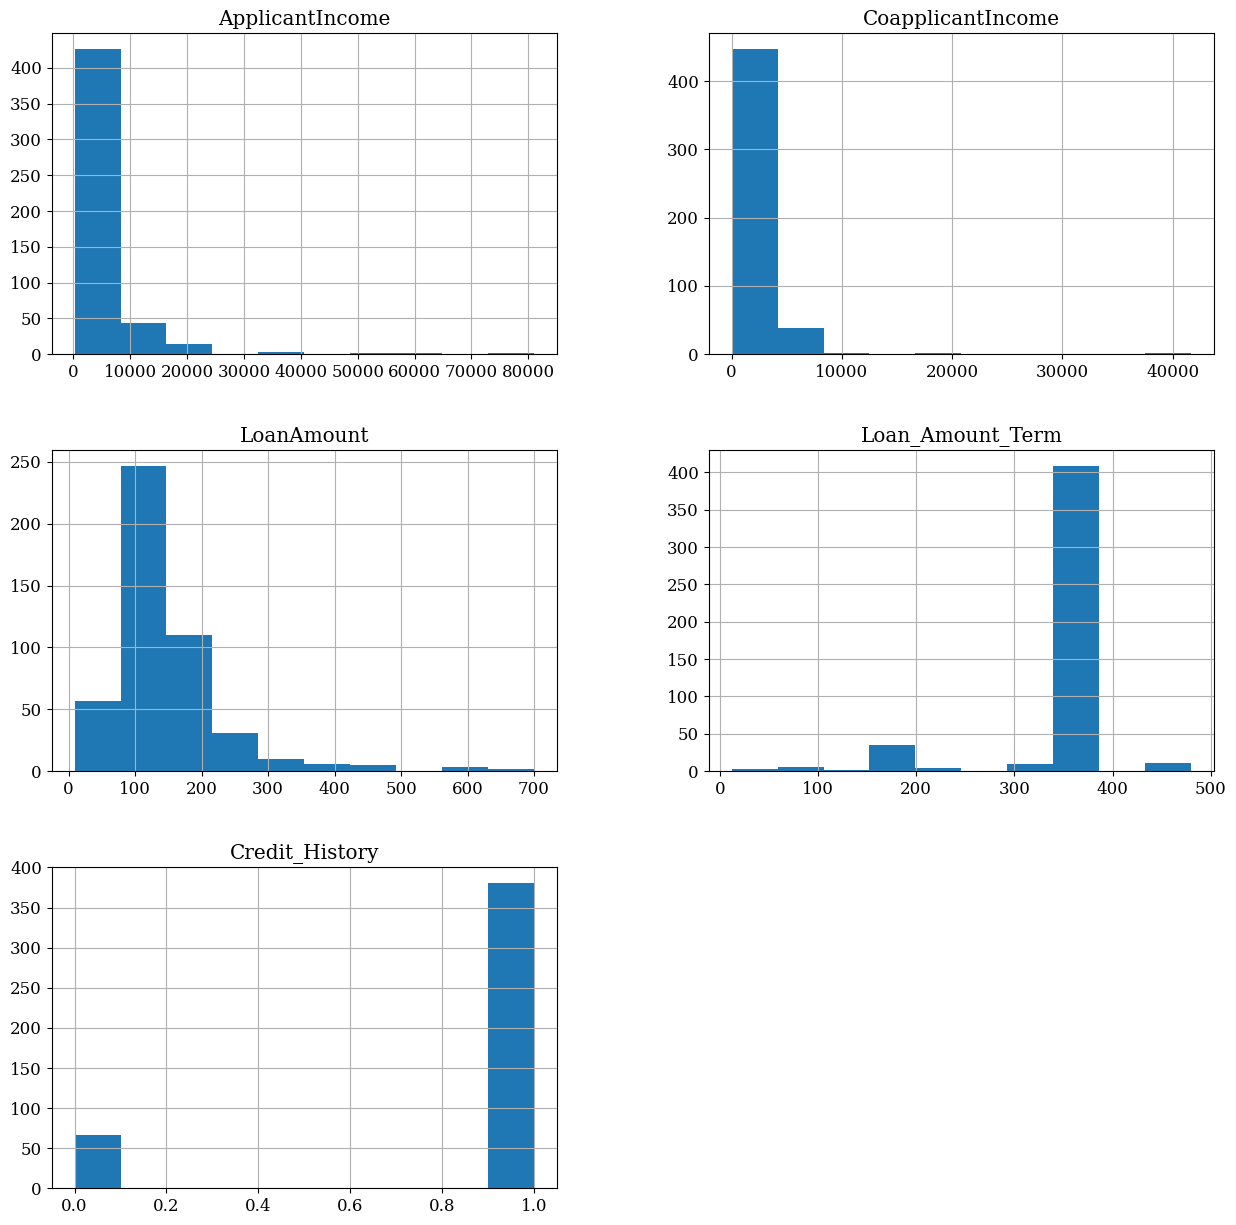

In [20]:
# Let's check the distribution of the columns
### CODE HERE ###
data.hist(figsize=(15,15));

## Data Preprocessing Pipeline

Before modeling, we preprocess the dataset by handling missing values, encoding categorical variables, and scaling numerical features if necessary. This ensures that the data is clean and properly formatted for training machine learning models.


In [21]:
# Let's complete the data analysis stage and define the preprocessing pipeline
### CODE HERE ###


NANs

In [22]:
# Contar el número de NaNs en cada fila
nan_counts = data.isnull().sum(axis=1)

# Obtener las columnas con NaNs en cada fila
nan_columns = data.apply(lambda row: [col for col in data.columns if pd.isnull(row[col])], axis=1)

# Crear un DataFrame con ambos resultados
nan_info = pd.DataFrame({'NaN_Count': nan_counts, 'NaN_Columns': nan_columns})

# Mostrar las primeras filas con más de 2 valores en NaNs
print(nan_info[nan_info['NaN_Count'] >= 2])

     NaN_Count                                  NaN_Columns
11           2                     [Dependents, LoanAmount]
150          2                     [Gender, Credit_History]
166          2              [Self_Employed, Credit_History]
198          2            [Self_Employed, Loan_Amount_Term]
219          2              [Self_Employed, Credit_History]
287          3  [Self_Employed, LoanAmount, Credit_History]
291          3            [Married, Dependents, LoanAmount]
363          2                        [Married, Dependents]
384          2              [Self_Employed, Credit_History]
444          2              [Self_Employed, Credit_History]
473          2                        [Married, Dependents]
478          2              [Self_Employed, Credit_History]


In [23]:
# Filtrar las filas donde la cantidad de NaNs sea menor a 2
data = data.loc[nan_info['NaN_Count'] < 2].copy()

# Reiniciar los índices
data.reset_index(drop=True, inplace=True)

In [24]:
data.isna().sum()

id                    0
Gender               10
Married               0
Dependents            4
Education             0
Self_Employed        20
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           17
Loan_Amount_Term     11
Credit_History       36
Property_Area         0
Loan_Status           0
dtype: int64

In [25]:
# Eliminar la columna 'id'
data = data.drop(columns=['id'])

In [26]:
unique_values = data['Dependents'].unique()
print(unique_values)

['0' '1' '2' '3+' nan]


In [27]:
# Contar la frecuencia de cada valor único
value_counts = data['Dependents'].value_counts()
print(value_counts)

Dependents
0     271
1      83
2      83
3+     38
Name: count, dtype: int64


In [28]:
# Reemplazar '3+' por 3
data['Dependents'] = data['Dependents'].replace({'3+': 3})

In [ ]:
# Corregir tipo de dato
data['Dependents'] = pd.to_numeric(data['Dependents'], errors='coerce')
data['Credit_History'] = pd.to_numeric(data['Credit_History'], errors='coerce')
data['ApplicantIncome'] = data['ApplicantIncome'].astype('float64')

In [ ]:
# Corregir formato
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data['Gender'] = pd.to_numeric(data['Gender'], errors='coerce')
data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})

In [ ]:
# One-hot encoding para 'Property_Area'
data = pd.get_dummies(data, columns=['Property_Area'], drop_first=True)

# Ahora convertir a entero
data['Property_Area_Semiurban'] = data['Property_Area_Semiurban'].astype('int64')
data['Property_Area_Urban'] = data['Property_Area_Urban'].astype('int64')

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   469 non-null    float64
 1   Married                  479 non-null    int64  
 2   Dependents               475 non-null    float64
 3   Education                479 non-null    int64  
 4   Self_Employed            459 non-null    float64
 5   ApplicantIncome          479 non-null    float64
 6   CoapplicantIncome        479 non-null    float64
 7   LoanAmount               462 non-null    float64
 8   Loan_Amount_Term         468 non-null    float64
 9   Credit_History           443 non-null    float64
 10  Loan_Status              479 non-null    int64  
 11  Property_Area_Semiurban  479 non-null    int64  
 12  Property_Area_Urban      479 non-null    int64  
dtypes: float64(8), int64(5)
memory usage: 48.8 KB


In [33]:
data.isna().sum()

Gender                     10
Married                     0
Dependents                  4
Education                   0
Self_Employed              20
ApplicantIncome             0
CoapplicantIncome           0
LoanAmount                 17
Loan_Amount_Term           11
Credit_History             36
Loan_Status                 0
Property_Area_Semiurban     0
Property_Area_Urban         0
dtype: int64

Imputar datos para los que tengan NANs

In [34]:
# Define the KNN imputer with the number of neighbors
knn_imputer = KNNImputer(n_neighbors=5)
data.iloc[:, :] = knn_imputer.fit_transform(data)
print(data.isnull().sum())


Gender                     0
Married                    0
Dependents                 0
Education                  0
Self_Employed              0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64


In [ ]:
# Corregir tipo de dato
data['Gender'] = data['Gender'].astype('int64')
data['Dependents'] = data['Dependents'].astype('int64')
data['Self_Employed'] = data['Self_Employed'].astype('int64')
data['Credit_History'] = data['Credit_History'].astype('int64')

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   479 non-null    int64  
 1   Married                  479 non-null    int64  
 2   Dependents               479 non-null    int64  
 3   Education                479 non-null    int64  
 4   Self_Employed            479 non-null    int64  
 5   ApplicantIncome          479 non-null    float64
 6   CoapplicantIncome        479 non-null    float64
 7   LoanAmount               479 non-null    float64
 8   Loan_Amount_Term         479 non-null    float64
 9   Credit_History           479 non-null    int64  
 10  Loan_Status              479 non-null    int64  
 11  Property_Area_Semiurban  479 non-null    int64  
 12  Property_Area_Urban      479 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 48.8 KB


# Model Training and Evaluation  

We train machine learning models, such as Random Forest, Gradient Boosting or XGBoost, to predict loan approval. The models are evaluated using appropriate metrics, and hyperparameter tuning is performed to optimize their performance.

In this section, we define the steps for training and evaluating the models.  

## Steps:  
1. **Define the hyperparameters**: Set initial values for model parameters.  
2. **Choose the cross-validation strategy**: Split the dataset into training and validation sets using an appropriate method.  
3. **Train the model**: Fit the model on training data using the defined hyperparameters.  
4. **Evaluate performance**: Use cross-validation to assess the model’s predictive ability.  
5. **Tune hyperparameters (if necessary)**: Optimize parameters for better performance.  

## Hyperparameters  
We define key hyperparameters for Random Forest and Gradient Boosting models, such as:  
- **n_estimators**: Number of trees in the ensemble.  
- **max_depth**: Maximum depth of each tree.  
- **learning_rate** (for boosting models): Controls step size for weight updates.  
- **min_samples_split**: Minimum samples required to split a node.  
- **min_samples_leaf**: Minimum samples required in a leaf node.  

## Cross-Validation Strategy  
To ensure reliable model evaluation, we use **K-Fold Cross-Validation**, which splits the dataset into **K** subsets (folds). The model is trained on **K-1** folds and tested on the remaining fold, repeating the process **K** times. This helps in reducing variance and providing a better generalization estimate.  




In [36]:
# Let's define the cross_validation
### CODE HERE ###

# Splitting the data into features (X) and target (y)
X = data.drop(columns=['Loan_Status'])
y = data['Loan_Status']

# Split into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameters for Random Forest
rf_params = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 10, 20], 
    'min_samples_split': [2, 5], 
    'min_samples_leaf': [1, 2]
}

# Hyperparameters for Gradient Boosting
gb_params = {
    'n_estimators': [100, 200], 
    'learning_rate': [0.01, 0.1, 0.2], 
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5], 
    'min_samples_leaf': [1, 2]
}

# Initialize the models
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Grid search with cross-validation for Random Forest
rf_grid = GridSearchCV(estimator=rf, param_grid=rf_params, cv=kf, scoring='f1')
rf_grid.fit(X_train, y_train)
print("Best hyperparameters for Random Forest: ", rf_grid.best_params_)

# Evaluate the best Random Forest model on the test set
rf_best_model = rf_grid.best_estimator_
rf_predictions = rf_best_model.predict(X_test)

print("Random Forest Model Evaluation:")
print("F1 Score: ", f1_score(y_test, rf_predictions))
print("Confusion Matrix: \n", confusion_matrix(y_test, rf_predictions))
print("Classification Report: \n", classification_report(y_test, rf_predictions))

# Grid search with cross-validation for Gradient Boosting
gb_grid = GridSearchCV(estimator=gb, param_grid=gb_params, cv=kf, scoring='f1')
gb_grid.fit(X_train, y_train)
print("Best hyperparameters for Gradient Boosting: ", gb_grid.best_params_)

# Evaluate the best Gradient Boosting model on the test set
gb_best_model = gb_grid.best_estimator_
gb_predictions = gb_best_model.predict(X_test)

print("Gradient Boosting Model Evaluation:")
print("F1 Score: ", f1_score(y_test, gb_predictions))
print("Confusion Matrix: \n", confusion_matrix(y_test, gb_predictions))
print("Classification Report: \n", classification_report(y_test, gb_predictions))

Best hyperparameters for Random Forest:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Model Evaluation:
F1 Score:  0.8571428571428571
Confusion Matrix: 
 [[16 14]
 [ 6 60]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.73      0.53      0.62        30
           1       0.81      0.91      0.86        66

    accuracy                           0.79        96
   macro avg       0.77      0.72      0.74        96
weighted avg       0.78      0.79      0.78        96

Best hyperparameters for Gradient Boosting:  {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Gradient Boosting Model Evaluation:
F1 Score:  0.8413793103448276
Confusion Matrix: 
 [[12 18]
 [ 5 61]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.71      0.40      0.51        30
           1       0.77     

El modelo Random Forest tuvo un mejor desempeño

# Finalizing the Model: Training a Full Pipeline  

Once the best model parameters have been selected, it is essential to **train a complete pipeline** that explicitly separates **data preprocessing** and **model training**. This ensures that preprocessing steps are consistently applied to both training and unseen data.  

## Steps:  
1. **Train the data preprocessing pipeline**:  
   - Handle missing values.  
   - Encode categorical features.  
   - Scale numerical features (if necessary).  

2. **Train the classification pipeline**:  
   - Use the entire processed training dataset and the best model hyperparameters to fit the selected model to make final predictions.  

3. **Save the trained pipelines**:  
   - The preprocessing and classification models should be saved for deployment and inference.  

By structuring the pipeline this way, we maintain consistency between training and real-world predictions while ensuring that preprocessing does not introduce **data leakage**.  


In [ ]:
# Let's train the full pipelines
### CODE HERE ###


In [ ]:
data = pd.read_csv('train.csv')

# Drop rows with 2 or more missing values and reset index
nan_counts = data.isnull().sum(axis=1)
data = data.loc[nan_counts < 2].copy()
data.reset_index(drop=True, inplace=True)

# Drop the 'id' column if it exists
if 'id' in data.columns:
    data = data.drop(columns=['id'])

class DataPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        data = X.copy()
        
        # Replace '3+' by 3 in the 'Dependents' column
        data['Dependents'] = data['Dependents'].replace({'3+': 3})
        
        # Define mapping for categorical columns
        mapping = {
            'Loan_Status': {'Y': 1, 'N': 0},
            'Married': {'Yes': 1, 'No': 0},
            'Gender': {'Male': 1, 'Female': 0},
            'Self_Employed': {'Yes': 1, 'No': 0},
            'Education': {'Graduate': 1, 'Not Graduate': 0}
        }
        
        for column, map_dict in mapping.items():
            if column in data.columns:
                data[column] = data[column].map(map_dict)
        
        # One-hot encoding for 'Property_Area'
        if 'Property_Area' in data.columns:
            property_dummies = pd.get_dummies(data['Property_Area'], prefix='Property_Area')
            if 'Property_Area_Rural' in property_dummies.columns:
                property_dummies.drop('Property_Area_Rural', axis=1, inplace=True)
            data = pd.concat([data.drop('Property_Area', axis=1), property_dummies], axis=1)
        
        # Convert columns to appropriate data types
        numeric_columns = ['Dependents', 'Credit_History', 'ApplicantIncome', 'Gender', 'Self_Employed']
        
        for col in numeric_columns:
            if col in data.columns:
                data[col] = pd.to_numeric(data[col], errors='coerce')
                data[col] = data[col].astype('float64')
             
				# Correct data types
        data['Gender'] = data['Gender'].astype('Int64')
        data['Dependents'] = data['Dependents'].astype('Int64')
        data['Self_Employed'] = data['Self_Employed'].astype('Int64')
        data['Credit_History'] = data['Credit_History'].astype('Int64')
        data['Property_Area_Semiurban'] = data['Property_Area_Semiurban'].astype('Int64')
        data['Property_Area_Urban'] = data['Property_Area_Urban'].astype('Int64')
				
        return data
    
class ArrayToDFTransformer(BaseEstimator, TransformerMixin):
    """
    Converts a numpy array back into a DataFrame using provided column names.
    """
    def __init__(self, columns=None):
        self.columns = columns
        
    def fit(self, X, y=None):
        if self.columns is None and isinstance(X, pd.DataFrame):
            self.columns = X.columns
        return self
    
    def transform(self, X, y=None):
        if self.columns is not None:
            return pd.DataFrame(X, columns=self.columns)
        return X

# Create a sample to capture the column names after preprocessing
X_train_sample = data.drop(columns=['Loan_Status']).copy()
preprocessed_sample = DataPreprocessor().fit_transform(X_train_sample)
columns_for_scaler = preprocessed_sample.columns.tolist()

# Build the preprocessing pipeline.
preprocessor = Pipeline([
    ('custom_preprocessor', DataPreprocessor()),
    ('imputer_scaler', Pipeline([
         ('imputer', KNNImputer(n_neighbors=5)),
         ('scaler', StandardScaler()),
         ('to_df', ArrayToDFTransformer(columns=columns_for_scaler))
    ]))
])


# Model Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, min_samples_leaf=2))
])

# Train and Test the Model
X = data.drop(columns=['Loan_Status'])
y = data['Loan_Status'].map({'Y': 1, 'N': 0})

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model_pipeline.fit(X_train, y_train)

# Evaluate the Model
y_pred = model_pipeline.predict(X_test)

# F1 Score and Classification Report
print(f'F1 Score: {f1_score(y_test, y_pred)}')
print(f'Classification Report: \n{classification_report(y_test, y_pred)}')

# Save the Full Pipeline
joblib.dump(model_pipeline, 'final_model_pipeline.pkl')

joblib.dump(model_pipeline.named_steps['preprocessor'], 'preprocessor.pkl');
joblib.dump(model_pipeline.named_steps['classifier'], 'classifier.pkl');

F1 Score: 0.8734177215189873
Classification Report: 
              precision    recall  f1-score   support

           0       0.78      0.28      0.41        25
           1       0.79      0.97      0.87        71

    accuracy                           0.79        96
   macro avg       0.79      0.63      0.64        96
weighted avg       0.79      0.79      0.75        96



# Applying the Pipelines for Prediction  

With the trained **data preprocessing** and **classification pipelines**, we can now apply them to the test dataset to generate predictions.  

## Steps:  
1. **Load the test dataset**: Ensure it has the same structure as the training data.  
2. **Apply the preprocessing pipeline**: Transform the test data using the trained preprocessing steps (e.g., encoding, scaling).  
3. **Make predictions**: Use the trained classification pipeline to predict loan approval outcomes.  
4. **Save or submit predictions**: Store the results for further analysis or competition submission.  

This structured approach ensures consistency and avoids data leakage, making the model reliable for real-world applications.  

In [ ]:
#!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1-03DcqzYIYtIAIt188ujy5Wr4GSdlgv5' -O loanpred_test.csv

--2025-02-03 15:51:30--  https://docs.google.com/uc?export=download&id=1-03DcqzYIYtIAIt188ujy5Wr4GSdlgv5
Resolving docs.google.com (docs.google.com)... 142.250.157.102, 142.250.157.138, 142.250.157.113, ...
Connecting to docs.google.com (docs.google.com)|142.250.157.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-03DcqzYIYtIAIt188ujy5Wr4GSdlgv5&export=download [following]
--2025-02-03 15:51:30--  https://drive.usercontent.google.com/download?id=1-03DcqzYIYtIAIt188ujy5Wr4GSdlgv5&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.97.132, 2404:6800:4008:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.97.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8358 (8.2K) [application/octet-stream]
Saving to: ‘loanpred_test.csv’

loanpred_test.csv   100%[===================>]   8.16K  --.-KB/s 

In [45]:
#Let's load the test data
test_df = pd.read_csv('test_no_label.csv')
test_df.head(5)

,id,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001528,Male,No,0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural
1,LP002804,Female,Yes,0,Graduate,No,4180,2306.0,182.0,360.0,1.0,Semiurban
2,LP002945,Male,Yes,0,Graduate,Yes,9963,0.0,180.0,360.0,1.0,Rural
3,LP001784,Male,Yes,1,Graduate,No,5500,1260.0,170.0,360.0,1.0,Rural
4,LP001514,Female,Yes,0,Graduate,No,2330,4486.0,100.0,360.0,1.0,Semiurban


In [46]:
# Let's make predictions
### CODE HERE ###

if 'id' in test_df.columns:
    test_ids = test_df['id']
    X_test = test_df.drop(columns=['id'])
else:
    X_test = test_df.copy()

full_pipeline = joblib.load('final_model_pipeline.pkl')
y_pred = full_pipeline.predict(X_test)

In [ ]:
# Save the results to a CSV file following the competition template
### CODE HERE ###
submission = pd.DataFrame({'id': test_df['id'], 'pred': y_pred})

submission.to_csv('loan_approval_predictions.csv', index=False)

# Explaining the Model with SHAP  

Understanding how a machine learning model makes predictions is crucial, especially in applications like loan approval, where fairness and transparency are key. **SHAP (SHapley Additive Explanations)** provides a way to interpret the contribution of each feature to a model’s predictions.  

## Why is SHAP Important?  
1. **Improves Trust and Transparency**: Helps explain why a loan was approved or rejected, making the decision process clearer.  
2. **Identifies Key Features**: Highlights which factors influence predictions the most, allowing for better feature selection and model refinement.  
3. **Detects Bias and Unfairness**: Reveals if certain features (e.g., gender, income) have unintended strong effects on decisions.  
4. **Enhances Model Debugging**: Helps diagnose issues like overfitting or unexpected feature dependencies.  

By using SHAP, we ensure that our model is interpretable and aligned with ethical and regulatory standards.  

In [ ]:
# Apply shap to explain
### CODE HERE ###

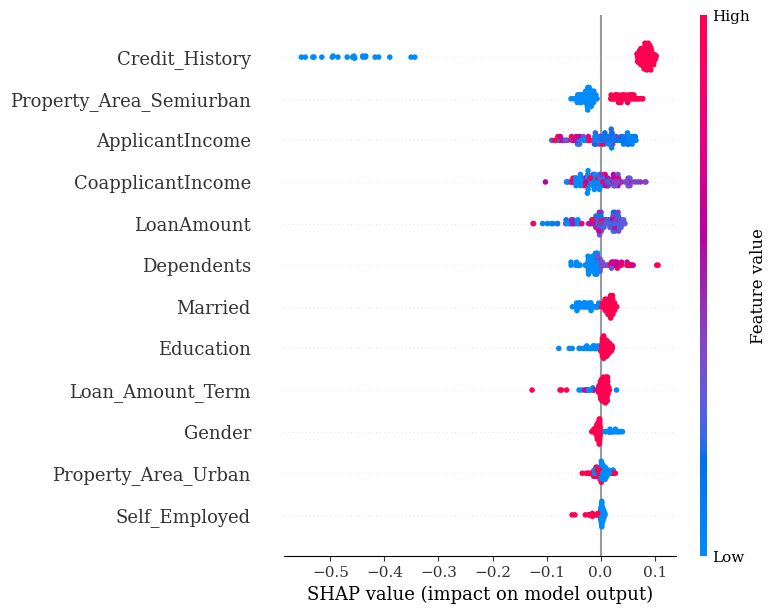

In [48]:
shap_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
             'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
             'Credit_History', 'Property_Area']
shap_cols = [col for col in shap_cols if col in X_test.columns]
X_test_shap = X_test[shap_cols].copy()

# Transform the test data using the pipeline's preprocessor.
X_test_transformed = full_pipeline.named_steps['preprocessor'].transform(X_test_shap)
feature_names = X_test_transformed.columns.tolist()

# Create a SHAP TreeExplainer using the classifier from the full pipeline.
classifier_loaded = full_pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(classifier_loaded)
shap_values = explainer.shap_values(X_test_transformed)

# Shap for approval (Loan_Status = 1) 
shap.summary_plot(shap_values[:,:,1], X_test_transformed, feature_names=feature_names)

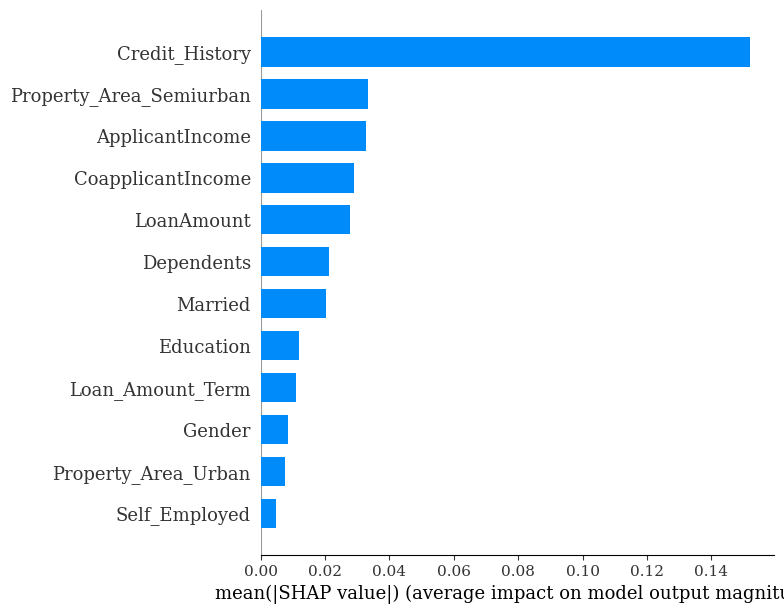

In [49]:
shap.summary_plot(shap_values[:,:,1], X_test_transformed, feature_names=feature_names, plot_type="bar")